Implementação do Perceptron 'clássico' proposto por Rosenblatt para classificação binária (classes 0 e 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Toymodel

In [ ]:
data = np.genfromtxt('toydata.txt', delimiter='\t')
X, y = data[:, :2], data[:, 2]
y = y.astype(int)

print('Class label counts:', np.bincount(y))
print('X.shape:', X.shape)
print('y.shape:', y.shape)

# Misturando os indices
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]

# Dividindo em conjuntos treino e teste (70/30)
X_train, X_test = X[shuffle_idx[:70]], X[shuffle_idx[70:]]
y_train, y_test = y[shuffle_idx[:70]], y[shuffle_idx[70:]]

# Normalizando (média 0, variancia unitária)
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# Verificando variacao
print('Variação por coluna de feature: ', X_train.std(axis=0))

Class label counts: [50 50]
X.shape: (100, 2)
y.shape: (100,)
Variação por coluna de feature:  [1. 1.]


Plot dos dados (2D)

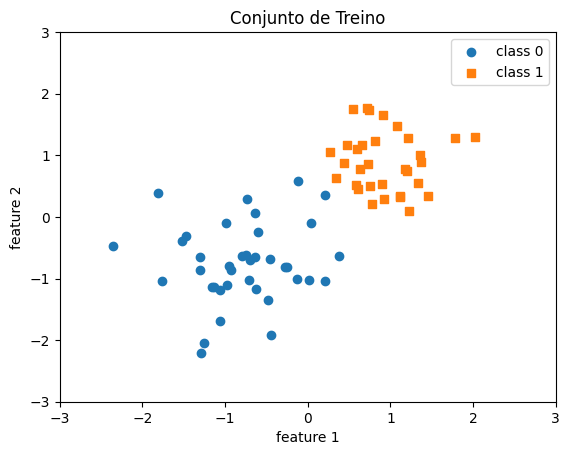

In [ ]:
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')
plt.title('Conjunto de Treino')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

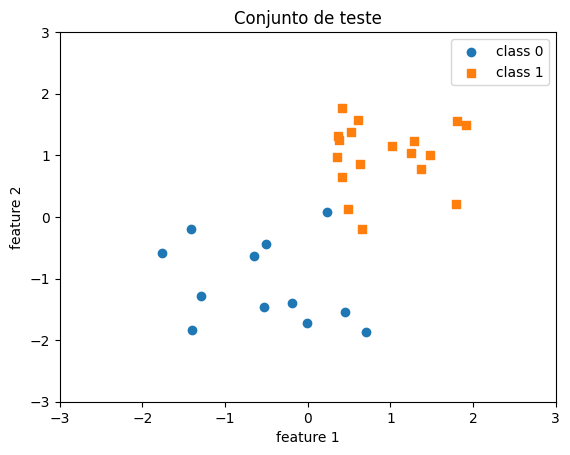

In [ ]:
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')
plt.title('Conjunto de teste')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

# Perceptron - Versão NumPy



In [ ]:
class Perceptron():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros((num_features, 1), dtype=float)
        self.bias = np.zeros(1, dtype=float)

    def forward(self, x):
        linear = np.dot(x, self.weights) + self.bias
        predictions = np.where(linear > 0., 1, 0)
        return predictions

    def backward(self, x, y):
        predictions = self.forward(x)
        errors = y - predictions
        return errors

    def train(self, x, y, epochs):
        for e in range(epochs):

            for i in range(y.shape[0]):
                errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
                self.weights += (errors * x[i]).reshape(self.num_features, 1)
                self.bias += errors

    def evaluate(self, x, y):
        predictions = self.forward(x).reshape(-1)
        accuracy = np.sum(predictions == y) / y.shape[0]
        return accuracy

Esse código implementa um Perceptron simples, um modelo básico de rede neural. Vou explicar cada parte do código detalhadamente e, em seguida, falar sobre a teoria que fundamenta o Perceptron.

---

### **1. Classe `Perceptron`**

O Perceptron é uma classe que encapsula os métodos e atributos necessários para treinar, avaliar e realizar inferências em um modelo simples.

#### **Construtor `__init__`**

```python
def __init__(self, num_features):
    self.num_features = num_features
    self.weights = np.zeros((num_features, 1), dtype=float)
    self.bias = np.zeros(1, dtype=float)
```

- `num_features`: número de features do dataset.
- `self.weights`: inicializa os pesos do Perceptron com zeros. O tamanho dos pesos corresponde ao número de features.
- `self.bias`: inicializa o bias com zero.

> O Perceptron aprende ajustando os valores desses pesos e do bias durante o treinamento.

---

### **2. Método `forward`**

```python
def forward(self, x):
    linear = np.dot(x, self.weights) + self.bias
    predictions = np.where(linear > 0., 1, 0)
    return predictions
```

- `np.dot(x, self.weights) + self.bias`: calcula a combinação linear entre as entradas e os pesos, adicionando o bias.
- `np.where(linear > 0., 1, 0)`: aplica a função de ativação degrau, retornando 1 se a saída for positiva e 0 caso contrário.

> Essa é a parte de inferência do Perceptron.

---

### **3. Método `backward`**

```python
def backward(self, x, y):  
    predictions = self.forward(x)
    errors = y - predictions
    return errors
```

- `predictions = self.forward(x)`: obtém as previsões para as entradas fornecidas.
- `errors = y - predictions`: calcula os erros entre as previsões e os valores reais.

> Esse método é importante para calcular os erros que serão usados na atualização dos pesos.

---

### **4. Método `train`**

```python
def train(self, x, y, epochs):
    for e in range(epochs):
        for i in range(y.shape[0]):
            errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
            self.weights += (errors * x[i]).reshape(self.num_features, 1)
            self.bias += errors
```

O treinamento ocorre em dois loops:

1. **Laço externo:** percorre o número de épocas definido.
2. **Laço interno:** percorre cada exemplo do dataset.

Durante o loop interno:

- Calcula o erro usando `backward`.
- Atualiza os pesos com a fórmula:
  
  $$w_j = w_j + \eta \cdot erro \cdot x_j$$
  
  onde $\eta$ é implicitamente 1 no código.
- Atualiza o bias:
  
  $$b = b + \eta \cdot erro$$
  

---

### **5. Método `evaluate`**

```python
def evaluate(self, x, y):
    predictions = self.forward(x).reshape(-1)
    accuracy = np.sum(predictions == y) / y.shape[0]
    return accuracy
```

- Realiza previsões para as entradas `x` e compara com as saídas reais `y`.
- Calcula a acurácia dividindo o número de previsões corretas pelo total de exemplos.

---

## **Teoria do Perceptron**

O Perceptron foi introduzido por Frank Rosenblatt em 1958 e é uma das redes neurais mais simples. Ele é utilizado para tarefas de classificação binária.

### **Funcionamento**

O Perceptron processa entradas $\mathbf{x} = [x_1, x_2, ..., x_n]$ e calcula uma saída $y$ de acordo com a seguinte equação:


$$z = \mathbf{w} \cdot \mathbf{x} + b$$


onde:
- $\mathbf{w}$ são os pesos associados às entradas,
- $b$ é o bias.

A saída $y$ é determinada pela função de ativação degrau:

$$
y =
\begin{cases}
1, & \text{se } z > 0 \\
0, & \text{caso contrário}
\end{cases}
$$

### **Treinamento**

Durante o treinamento, os pesos e o bias são ajustados com base no erro entre a saída prevista e a desejada.

1. **Predição:** $y_{previsto} = f(\mathbf{w} \cdot \mathbf{x} + b)$
2. **Erro:** $erro = y_{real} - y_{previsto}$
3. **Atualização dos pesos:** $w_j = w_j + \eta \cdot erro \cdot x_j$
4. **Atualização do bias:** $b = b + \eta \cdot erro$

Onde $\eta$ é a taxa de aprendizado. No código acima, ela é implicitamente 1.

---

### **Limitações do Perceptron**

- **Linearidade:** O Perceptron só é capaz de classificar dados que são linearmente separáveis.
- **Função de ativação simples:** A ativação degrau não permite uma boa modelagem de fronteiras de decisão complexas.
- **Taxa de aprendizado fixa:** Não há controle explícito da taxa de aprendizado.

---

### **Conclusão**

O Perceptron é um modelo básico, mas fundamental para entender redes neurais mais complexas. Ele foi o ponto de partida para o desenvolvimento de redes multicamadas (MLPs) e a introdução de funções de ativação não-lineares, que resolveram muitas de suas limitações.

Treinando o Perceptron

In [ ]:
ppn = Perceptron(num_features=2)

ppn.train(X_train, y_train, epochs=5)

print('Model parameters:\n\n')
print('  Weights: %s\n' % ppn.weights)
print('  Bias: %s\n' % ppn.bias)

Model parameters:


  Weights: [[1.27340847]
 [1.34642288]]

  Bias: [-1.]



Avaliando o modelo

In [ ]:
train_acc = ppn.evaluate(X_train, y_train)
print('Train set accuracy: %.2f%%' % (train_acc*100))

Train set accuracy: 100.00%


In [ ]:
test_acc = ppn.evaluate(X_test, y_test)
print('Test set accuracy: %.2f%%' % (test_acc*100))

Test set accuracy: 93.33%


Verificando o limite

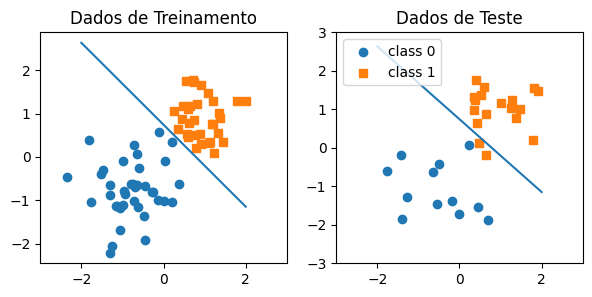

In [ ]:
w, b = ppn.weights, ppn.bias

x0_min = -2
x1_min = ( (-(w[0] * x0_min) - b[0])
          / w[1] )

x0_max = 2
x1_max = ( (-(w[0] * x0_max) - b[0])
          / w[1] )

# x0*w0 + x1*w1 + b = 0
# x1  = (-x0*w0 - b) / w1


fig, ax = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

ax[0].plot([x0_min, x0_max], [x1_min, x1_max])
ax[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
ax[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')

ax[1].plot([x0_min, x0_max], [x1_min, x1_max])
ax[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
ax[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')

ax[0].set_title('Dados de Treinamento')
ax[1].set_title('Dados de Teste')
plt.xlim(-3, 3)
plt.ylim(-3, 3)

ax[1].legend(loc='upper left')
plt.show()

Essa parte do código constrói gráficos que mostram a fronteira de decisão do Perceptron em relação aos dados de treinamento e teste, visualizando como o modelo separa as classes com base em seus pesos.

---

### **Entendendo a Fronteira de Decisão**
A equação usada para desenhar a reta da fronteira de decisão é derivada da seguinte condição do Perceptron:


$$w_0 \cdot x_0 + w_1 \cdot x_1 + b = 0$$

Para encontrar $x_1$ em função de $x_0$, isolamos $x_1$:


$$x_1 = \frac{-(w_0 \cdot x_0 + b)}{w_1}$$

Essa equação define uma linha no espaço bidimensional que separa as classes.

---

### **Interpretação do Código**

```python
w, b = ppn.weights, ppn.bias
```
- Obtém os pesos e o bias treinados pelo Perceptron.

---

#### **Cálculo dos pontos extremos da reta**
Os valores $x_0_{min}$ e $x_0_{max}$ são definidos manualmente para cobrir a área do gráfico. Com isso, calculamos os respectivos valores de $x_1$ usando a equação da reta.

```python
x0_min = -2
x1_min = (-(w[0] * x0_min) - b[0]) / w[1]

x0_max = 2
x1_max = (-(w[0] * x0_max) - b[0]) / w[1]
```

- $x_0$ varia de -2 a 2.
- Para cada valor de $x_0$, o valor correspondente de $x_1$ é calculado com a equação da fronteira.

---

### **Gráficos com `matplotlib`**

```python
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(7, 3))
```
- Cria dois gráficos lado a lado com a mesma escala no eixo X.

#### **Gráfico de Treinamento**
```python
ax[0].plot([x0_min, x0_max], [x1_min, x1_max])
ax[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
ax[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')
```
- Plota a linha da fronteira de decisão determinada pelo Perceptron.
- Adiciona os pontos de treinamento para as classes 0 e 1 com marcadores diferentes.

#### **Gráfico de Teste**
```python
ax[1].plot([x0_min, x0_max], [x1_min, x1_max])
ax[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
ax[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')
ax[1].legend(loc='upper left')
```
- Plota novamente a linha da fronteira de decisão.
- Adiciona os pontos de teste para visualizar se o modelo conseguiu separar bem as classes.

---

### **Observações**

- **Interpretação da Fronteira:** A linha desenhada representa onde o Perceptron prevê a transição entre uma classe e outra $(f(x) = 0)$. Os pontos acima e abaixo dessa linha são classificados em classes diferentes.
- **Reta Linear:** Como o Perceptron só resolve problemas linearmente separáveis, a fronteira será sempre uma reta.


# Perceptron - Versão pyTorch

In [ ]:
import torch

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


class PerceptronPyTorch():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = torch.zeros(num_features, 1,
                                   dtype=torch.float32, device=device)
        self.bias = torch.zeros(1, dtype=torch.float32, device=device)

        # Alocando os vetores para não ter que criar a todo momento
        self.ones = torch.ones(1)
        self.zeros = torch.zeros(1)

    def forward(self, x):
        linear = torch.mm(x, self.weights) + self.bias
        predictions = torch.where(linear > 0., self.ones, self.zeros)
        return predictions

    def backward(self, x, y):
        predictions = self.forward(x)
        errors = y - predictions
        return errors

    def train(self, x, y, epochs):
        for e in range(epochs):

            for i in range(y.shape[0]):
                # use view because backward expects a matrix (i.e., 2D tensor)
                errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
                self.weights += (errors * x[i]).reshape(self.num_features, 1)
                self.bias += errors

    def evaluate(self, x, y):
        predictions = self.forward(x).reshape(-1)
        accuracy = torch.sum(predictions == y).float() / y.shape[0]
        return accuracy

Esse código implementa um Perceptron utilizando PyTorch, uma biblioteca amplamente usada para machine learning e redes neurais, especialmente em tarefas que se beneficiam do uso de GPUs.

---

### **1. Inicialização do `device`**

```python
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
```
- Define o dispositivo de execução do modelo.
- Se uma GPU CUDA estiver disponível, o modelo será executado nela; caso contrário, será executado na CPU.

---

### **2. Classe `PerceptronPyTorch`**

#### **Construtor `__init__`**

```python
def __init__(self, num_features):
    self.num_features = num_features
    self.weights = torch.zeros(num_features, 1, dtype=torch.float32, device=device)
    self.bias = torch.zeros(1, dtype=torch.float32, device=device)
    
    self.ones = torch.ones(1)  # Placeholder para prever classe 1
    self.zeros = torch.zeros(1)  # Placeholder para prever classe 0
```

- `self.weights`: inicializa os pesos com zeros e os aloca no dispositivo definido.
- `self.bias`: inicializa o bias com zero no mesmo dispositivo.
- `self.ones` e `self.zeros`: placeholders para as previsões, usados na função `torch.where`. Isso evita recriações desnecessárias desses tensores.

---

#### **3. Método `forward`**

```python
def forward(self, x):
    linear = torch.mm(x, self.weights) + self.bias
    predictions = torch.where(linear > 0., self.ones, self.zeros)
    return predictions
```
- `torch.mm(x, self.weights)`: realiza a multiplicação matricial (produto escalar entre as entradas e os pesos).
- `torch.where(linear > 0., self.ones, self.zeros)`: aplica a função de ativação degrau, retornando 1 se a saída for positiva e 0 caso contrário.

> **Nota:** A operação `torch.mm` é equivalente a `np.dot` no NumPy.

---

#### **4. Método `backward`**

```python
def backward(self, x, y):  
    predictions = self.forward(x)
    errors = y - predictions
    return errors
```

- Calcula os erros entre as previsões e os valores reais, como na versão NumPy.

---

#### **5. Método `train`**

```python
def train(self, x, y, epochs):
    for e in range(epochs):
        for i in range(y.shape[0]):
            errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
            self.weights += (errors * x[i]).reshape(self.num_features, 1)
            self.bias += errors
```

Durante o treinamento:

- Para cada exemplo no dataset, calcula o erro com `backward`.
- Atualiza os pesos e o bias de acordo com a fórmula do Perceptron:
  
  $$w_j = w_j + erro \cdot x_j$$

- Utiliza `reshape` para manter o formato correto dos tensores.

> A operação `torch.reshape` é equivalente a `np.reshape` do NumPy.

---

#### **6. Método `evaluate`**

```python
def evaluate(self, x, y):
    predictions = self.forward(x).reshape(-1)
    accuracy = torch.sum(predictions == y).float() / y.shape[0]
    return accuracy
```

- Calcula as previsões para as entradas fornecidas.
- Compara com as saídas reais e calcula a acurácia.

---

### **Principais Diferenças em Relação ao Código NumPy**

1. **Operações com Tensors:**
   - Utiliza `torch.mm` para multiplicação matricial e `torch.where` para aplicar a função de ativação.
   - As operações são automaticamente diferenciáveis em PyTorch, embora o código não faça backpropagation explícito.

2. **Uso do Dispositivo:**
   - Os pesos e tensores são alocados em GPU quando disponível, acelerando o treinamento.

3. **Placeholder para Previsões:**
   - Mantém `self.ones` e `self.zeros` para evitar recriações desnecessárias, otimizando a execução.



In [ ]:
ppn = PerceptronPyTorch(num_features=2)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)

ppn.train(X_train_tensor, y_train_tensor, epochs=5)

print('Model parameters:')
print('  Weights: %s' % ppn.weights)
print('  Bias: %s' % ppn.bias)

Model parameters:
  Weights: tensor([[1.2734],
        [1.3464]])
  Bias: tensor([-1.])


In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=device)

test_acc = ppn.evaluate(X_test_tensor, y_test_tensor)
print('Test set accuracy: %.2f%%' % (test_acc*100))

Test set accuracy: 93.33%


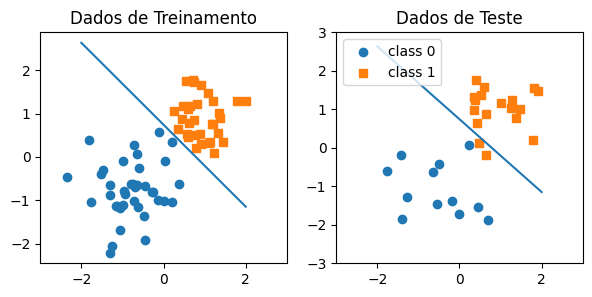

In [ ]:
w, b = ppn.weights, ppn.bias

x0_min = -2
x1_min = ( (-(w[0] * x0_min) - b[0])
          / w[1] )

x0_max = 2
x1_max = ( (-(w[0] * x0_max) - b[0])
          / w[1] )

# x0*w0 + x1*w1 + b = 0
# x1  = (-x0*w0 - b) / w1


fig, ax = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

ax[0].plot([x0_min, x0_max], [x1_min, x1_max])
ax[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
ax[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')

ax[1].plot([x0_min, x0_max], [x1_min, x1_max])
ax[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
ax[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')

ax[0].set_title('Dados de Treinamento')
ax[1].set_title('Dados de Teste')
plt.xlim(-3, 3)
plt.ylim(-3, 3)

ax[1].legend(loc='upper left')
plt.show()

# Perceptron - Versão Sklearn

referência: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html#perceptron

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

In [ ]:
perceptron = Perceptron(random_state = 42, max_iter = 10)
perceptron.fit(X_train, y_train)
test_preds = perceptron.predict(X_test)

In [ ]:
test_accuracy = accuracy_score(test_preds, y_test)
print(test_accuracy)

0.9333333333333333


In [ ]:
# Plot da fronteira de decisão
def plot_decision_boundary(model, X, y):
    # Criando uma malha de pontos para preencher o gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Prevendo a classe para cada ponto na malha
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotando a região de decisão
    plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title("Fronteira de Decisão - Perceptron")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

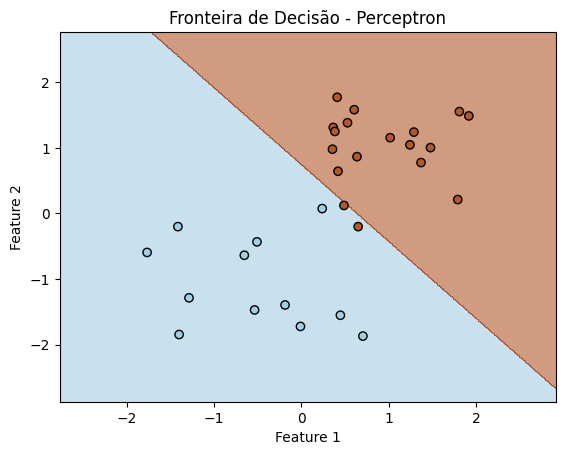

In [ ]:
plot_decision_boundary(perceptron, X_test, y_test)

Vamos testar agora com outro dataset nosso para verificar as predições em outro cenário

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('credit_data.csv')
df = df[df['age']>0].dropna()
df.drop(['clientid'], axis=1, inplace=True)
df['age'] = df['age'].apply(lambda x: int(x))
df.head()

,income,age,loan,default
0,66155.925095,59,8106.532131,0
1,34415.153966,48,6564.745018,0
2,57317.170063,63,8020.953296,0
3,42709.534201,45,6103.642260,0
4,66952.688845,18,8770.099235,1


In [ ]:
# Dividindo os dados primeiro

X = df.drop(columns=['default'], axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Sklearn version
perceptron = Perceptron(random_state = 42, max_iter = 30)
perceptron.fit(X_train, y_train)
test_preds = perceptron.predict(X_test)

In [ ]:
test_accuracy = accuracy_score(test_preds, y_test)
print(test_accuracy)

0.8571428571428571


In [ ]:
# Pytorch version
ppn = PerceptronPyTorch(num_features=X_train.shape[1])

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32, device=device)

ppn.train(X_train_tensor, y_train_tensor, epochs=30)

print('Model parameters:')
print('  Weights: %s' % ppn.weights)
print('  Bias: %s' % ppn.bias)

Model parameters:
  Weights: tensor([[-105861.1875],
        [-105739.0000],
        [ 521010.9688]])
  Bias: tensor([-77.])


In [ ]:
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32, device=device)

test_acc = ppn.evaluate(X_test_tensor, y_test_tensor)
print('Test set accuracy: %.2f%%' % (test_acc*100))

Test set accuracy: 85.71%
